# Indexing

`rt.index` shows how an indexing expression selects elements. The selected cells fill green and the selected frames keep their colour while the rest dim.

In [1]:
import numpy as np

import rainbow_tensor as rt

## Integers and slices

An integer drops an axis. A slice keeps it. Here axis 1 survives as a slice.

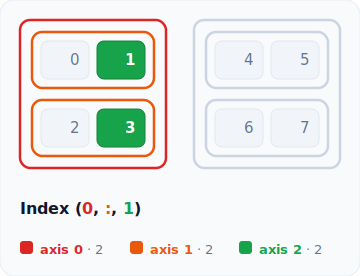

Original shape: (2, 2, 2)
Index: 0, :, 1
Result shape: (2,)
Axis 0 is removed because integer index 0 is used.
Axis 1 is kept because slice : is used.
Axis 2 is removed because integer index 1 is used.


In [2]:
x = np.arange(8).reshape(2, 2, 2)
rt.index(x, (0, slice(None), 1))

## Negative, stepped, and reversed

Negative bounds and steps resolve the same way as NumPy. `4:1:-1` walks backwards.

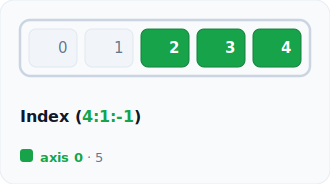

Original shape: (5,)
Index: 4:1:-1
Result shape: (3,)
Axis 0 is kept because slice 4:1:-1 is used.


In [3]:
rt.index(np.arange(5), (slice(4, 1, -1),))

## Ellipsis and a new axis

`...` fills the axes you leave out and `None` inserts a size one axis.

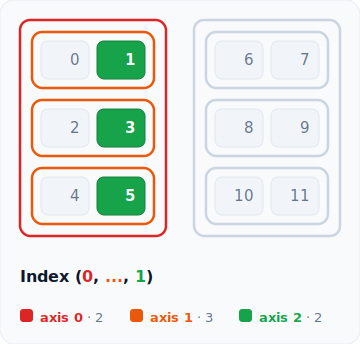

Original shape: (2, 3, 2)
Index: 0, ..., 1
Result shape: (3,)
Axis 0 is removed because integer index 0 is used.
Axis 1 is kept because slice : is used.
Axis 2 is removed because integer index 1 is used.


In [4]:
rt.index(np.arange(12).reshape(2, 3, 2), (0, ..., 1))

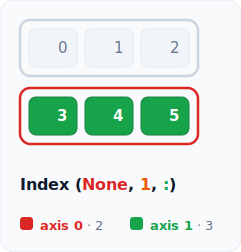

Original shape: (2, 3)
Index: None, 1, :
Result shape: (1, 3)
A new size 1 axis is inserted by None at result position 0.
Axis 0 is removed because integer index 1 is used.
Axis 1 is kept because slice : is used.


In [5]:
rt.index(np.arange(6).reshape(2, 3), (None, 1, slice(None)))

## Boolean masks

A boolean mask of matching shape highlights every True position.

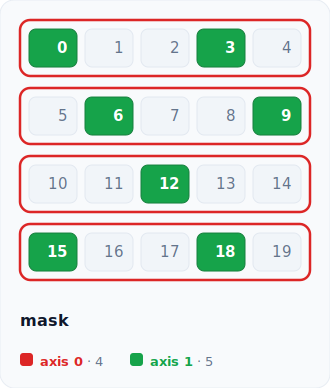

Original shape: (4, 5)
Advanced indexing with a boolean mask.
The mask keeps 7 elements where it is True.
Result shape: (7,)


In [6]:
x = np.arange(20).reshape(4, 5)
rt.index(x, x % 3 == 0)

## Fancy indexing

Integer arrays gather coordinates. Paired arrays pick one element each.

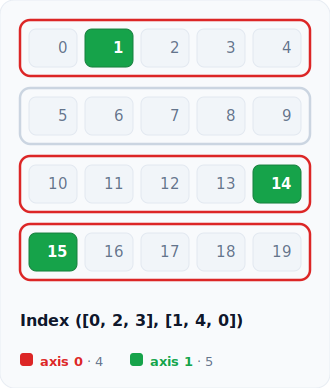

Original shape: (4, 5)
Index: [0, 2, 3], [1, 4, 0]
Advanced indexing with integer arrays.
Axes 0, 1 gather 3 positions in shape (3,).
Result shape: (3,)


In [7]:
x = np.arange(20).reshape(4, 5)
rt.index(x, ([0, 2, 3], [1, 4, 0]))

## Clear errors

An out of range index points at the offending axis instead of failing deep inside NumPy.

In [8]:
x = np.arange(8).reshape(2, 2, 2)
try:
    rt.index(x, (2, slice(None), 1))
except IndexError as error:
    print(error)

axis 0: index 2 is out of range for size 2
